In [ ]:
Load and Prepare Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
 
# Load dataset
df = pd.read_csv('../data/train.csv')
 
# Repeat the same cleaning steps from Block 2
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Discount'] = df['Discount'].map({'Yes': 1, 'No': 0})
df.drop_duplicates(inplace=True)
 
print('Data loaded. Shape:', df.shape)
df.head()


Data loaded. Shape: (188340, 15)


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales,Year,Month,Day,DayOfWeek,WeekOfYear
0,T1000001,1,S1,L3,R1,2018-01-01,1,1,9,7011.84,2018,1,1,0,1
1,T1000002,253,S4,L2,R1,2018-01-01,1,1,60,51789.12,2018,1,1,0,1
2,T1000003,252,S3,L2,R1,2018-01-01,1,1,42,36868.20,2018,1,1,0,1
3,T1000004,251,S2,L3,R1,2018-01-01,1,1,23,19715.16,2018,1,1,0,1
4,T1000005,250,S2,L3,R4,2018-01-01,1,1,62,45614.52,2018,1,1,0,1


In [ ]:
Feature Engineering

In [3]:
# Is it a weekend?
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
 
# Is it start or end of month? (often different buying patterns)
df['IsMonthStart'] = (df['Day'] <= 5).astype(int)
df['IsMonthEnd'] = (df['Day'] >= 25).astype(int)
 
# Quarter of the year
df['Quarter'] = df['Month'].apply(lambda x: (x-1)//3 + 1)
 
# Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)
def get_season(month):
    if month in [12, 1, 2]: return 1   # Winter
    elif month in [3, 4, 5]: return 2  # Spring
    elif month in [6, 7, 8]: return 3  # Summer
    else: return 4                      # Fall
 
df['Season'] = df['Month'].apply(get_season)
 
print('New features added. Total columns:', df.shape[1])
print(df[['IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Quarter', 'Season']].head())


New features added. Total columns: 20
   IsWeekend  IsMonthStart  IsMonthEnd  Quarter  Season
0          0             1           0        1       1
1          0             1           0        1       1
2          0             1           0        1       1
3          0             1           0        1       1
4          0             1           0        1       1


In [ ]:
Encode Categorical Variables

In [4]:
# Encode categorical columns using Label Encoding
le = LabelEncoder()
 
cat_cols = ['Store_Type', 'Location_Type', 'Region_Code']
for col in cat_cols:
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    print(f'{col} unique values: {df[col].unique()}')
    print(f'  -> Encoded as: {df[col+"_encoded"].unique()}')
    print()
 
print('Categorical encoding complete.')


Store_Type unique values: ['S1' 'S4' 'S3' 'S2']
  -> Encoded as: [0 3 2 1]

Location_Type unique values: ['L3' 'L2' 'L1' 'L5' 'L4']
  -> Encoded as: [2 1 0 4 3]

Region_Code unique values: ['R1' 'R4' 'R2' 'R3']
  -> Encoded as: [0 3 1 2]

Categorical encoding complete.


In [ ]:
Prepare Features and Target

In [5]:
# Define features (X) and target (y)
FEATURES = [
    'Store_Type_encoded', 'Location_Type_encoded', 'Region_Code_encoded',
    'Holiday', 'Discount',
    'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Quarter', 'Season',
    '#Order'
]
 
TARGET = 'Sales'
 
X = df[FEATURES]
y = df[TARGET]
 
print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeatures used: {FEATURES}')


Features shape: (188340, 16)
Target shape:   (188340,)

Features used: ['Store_Type_encoded', 'Location_Type_encoded', 'Region_Code_encoded', 'Holiday', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Quarter', 'Season', '#Order']


In [ ]:
Train-Test Split

In [6]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f'Training set size:  {X_train.shape[0]} rows')
print(f'Testing set size:   {X_test.shape[0]} rows')
 
# Scale the features (important for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size:  150672 rows
Testing set size:   37668 rows


In [ ]:
Train Multiple Models

In [7]:
# Define a function to evaluate any model
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    model.fit(X_tr, y_tr)              # Train
    y_pred = model.predict(X_te)        # Predict on test set
 
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)
 
    print(f'--- {model_name} ---')
    print(f'  MAE:  {mae:,.2f}    (lower is better)')
    print(f'  RMSE: {rmse:,.2f}   (lower is better)')
    print(f'  R²:   {r2:.4f}   (closer to 1.0 is better)')
    print()
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
 
results = []
 
# 1. Linear Regression (Baseline)
lr = LinearRegression()
results.append(evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression'))
 
# 2. Decision Tree
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree'))
 
# 3. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest'))
 
# 4. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
results.append(evaluate_model(gb, X_train, X_test, y_train, y_test, 'Gradient Boosting'))
 
# 5. XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
results.append(evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost'))


--- Linear Regression ---
  MAE:  3,982.45    (lower is better)
  RMSE: 5,400.14   (lower is better)
  R²:   0.9137   (closer to 1.0 is better)

--- Decision Tree ---
  MAE:  3,682.19    (lower is better)
  RMSE: 5,057.56   (lower is better)
  R²:   0.9243   (closer to 1.0 is better)

--- Random Forest ---
  MAE:  2,390.23    (lower is better)
  RMSE: 3,425.18   (lower is better)
  R²:   0.9653   (closer to 1.0 is better)

--- Gradient Boosting ---
  MAE:  2,638.35    (lower is better)
  RMSE: 3,733.93   (lower is better)
  R²:   0.9588   (closer to 1.0 is better)

--- XGBoost ---
  MAE:  2,178.68    (lower is better)
  RMSE: 3,180.51   (lower is better)
  R²:   0.9701   (closer to 1.0 is better)



In [ ]:
Compare Model Results

=== MODEL COMPARISON (sorted by RMSE) ===
            Model         MAE        RMSE       R2
          XGBoost 2178.677626 3180.508320 0.970079
    Random Forest 2390.234520 3425.177744 0.965298
Gradient Boosting 2638.351929 3733.932954 0.958760
    Decision Tree 3682.191655 5057.560483 0.924339
Linear Regression 3982.446285 5400.135909 0.913743


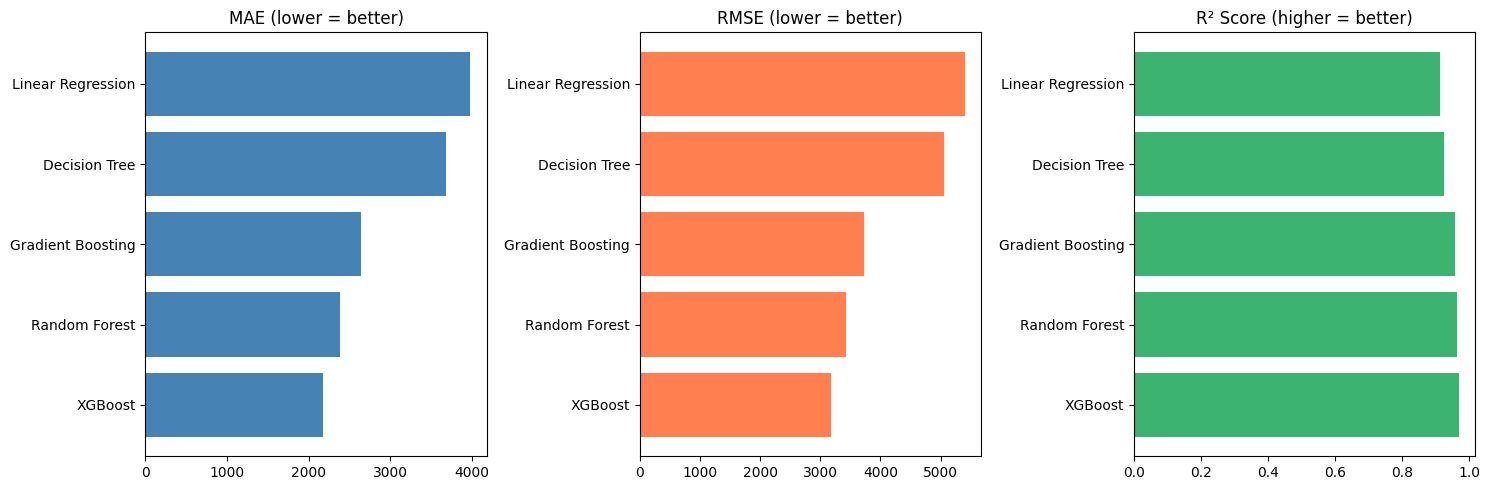


Best model: XGBoost


In [8]:
# Create a comparison dataframe
results_df = pd.DataFrame(results).sort_values('RMSE')
print('=== MODEL COMPARISON (sorted by RMSE) ===')
print(results_df.to_string(index=False))
 
# Plot the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
axes[0].barh(results_df['Model'], results_df['MAE'], color='steelblue')
axes[0].set_title('MAE (lower = better)')
 
axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_title('RMSE (lower = better)')
 
axes[2].barh(results_df['Model'], results_df['R2'], color='mediumseagreen')
axes[2].set_title('R² Score (higher = better)')
 
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 
best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')


In [ ]:
Feature Importance

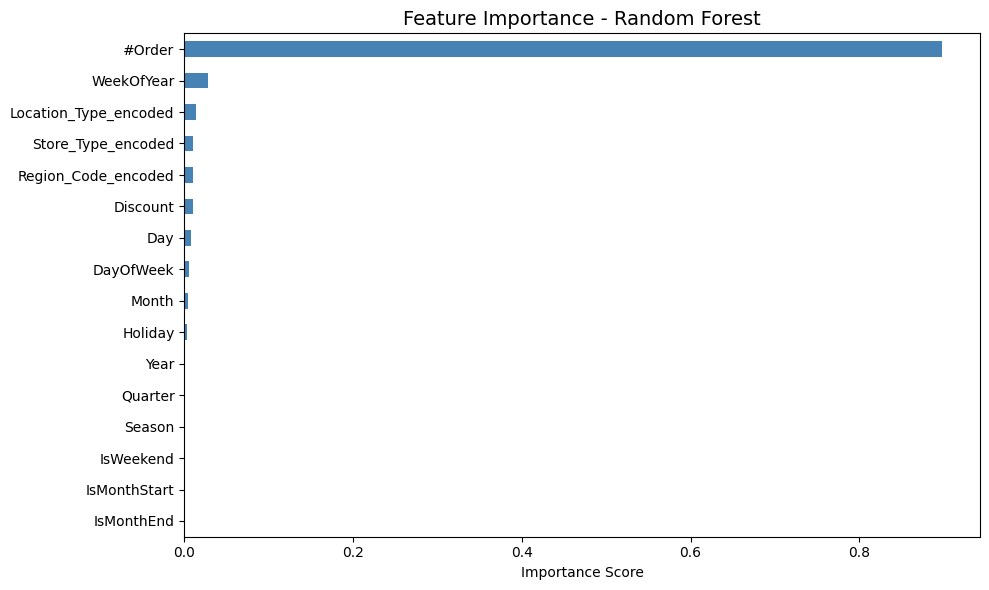

Top 5 most important features:
#Order                   0.898101
WeekOfYear               0.027683
Location_Type_encoded    0.014518
Store_Type_encoded       0.010989
Region_Code_encoded      0.010948
dtype: float64


In [9]:
# Show which features matter most (for tree-based models)
# Use Random Forest for feature importance
feature_importance = pd.Series(rf.feature_importances_, index=FEATURES)
feature_importance = feature_importance.sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('Top 5 most important features:')
print(feature_importance.head())


In [ ]:
Actual vs Predicted Plot

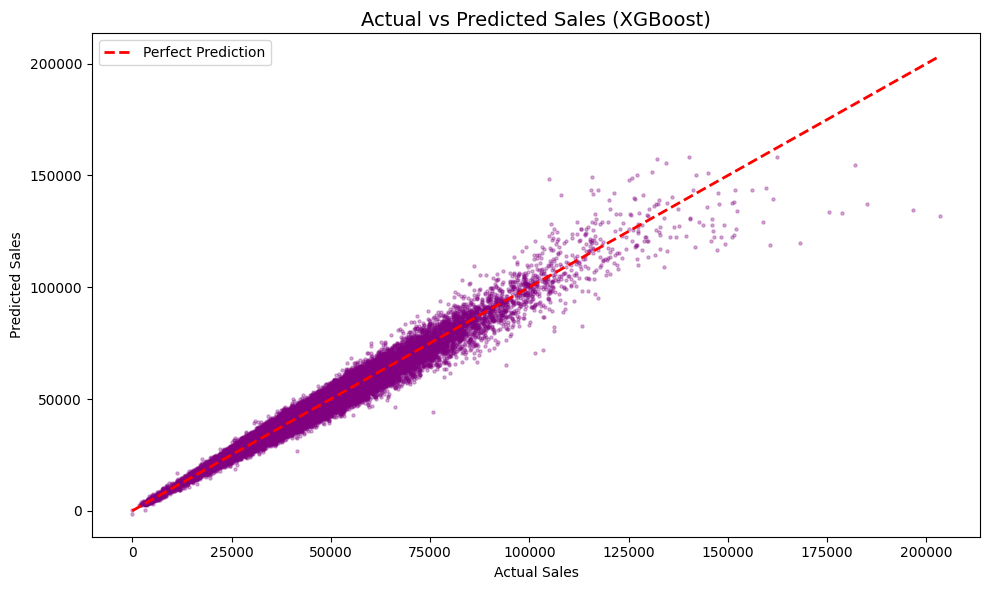

In [10]:
# Visualize how close predictions are to actual values
# Using XGBoost (or replace with your best model)
y_pred_xgb = xgb_model.predict(X_test)
 
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='purple', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (XGBoost)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
Save the Best Model

In [11]:
import joblib
import os
 
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)
 
# Save the best model (XGBoost or Random Forest — whichever scored best)
joblib.dump(xgb_model, '../models/best_model.pkl')
 
# Also save the scaler and the feature list
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(FEATURES, '../models/features.pkl')
 
print('Model saved to: ../models/best_model.pkl')
print('Scaler saved to: ../models/scaler.pkl')
print('Features saved to: ../models/features.pkl')
 
# Verify it loads correctly
loaded_model = joblib.load('../models/best_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print(f'\nTest prediction (first 5 rows): {test_pred}')
print('Model loaded and working correctly!')


Model saved to: ../models/best_model.pkl
Scaler saved to: ../models/scaler.pkl
Features saved to: ../models/features.pkl

Test prediction (first 5 rows): [35897.605 64915.086 40245.105 34112.832 36360.156]
Model loaded and working correctly!
